# Exercício 1: Teorema Central do Limite

Considere o **Teorema Central do Limite (TCL)**. Sejam $X_1, \ldots, X_n$ variáveis aleatórias i.i.d., com média $\mu$ e variância finita $\sigma^2$. Então,

$$
\frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}
\xrightarrow{d}
N(0,1),
$$

quando $n \to \infty$.

O objetivo deste exercício é verificar empiricamente o comportamento descrito pelo TCL para diferentes distribuições e diferentes valores de $n$.

1. Considere as seguintes distribuições para $X$:

   * Uniforme;
   * Bernoulli;
   * Geométrica;
   * Poisson.

   Para cada distribuição, escolha diferentes valores de $n$ e gere $M = 5000$ realizações da variável aleatória

   $$
   Z_n = \frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}.
   $$

   Compare o comportamento da distribuição de $Z_n$ conforme o valor de $n$ aumenta.

2. Para cada distribuição e para cada valor de $n$, construa um histograma das $M = 5000$ realizações de $Z_n$.

   Compare os histogramas obtidos com uma amostra de uma distribuição normal padrão $N(0,1)$ gerada diretamente pelo NumPy.

3. Analise os resultados obtidos e discuta:

   * como a aproximação pela distribuição normal muda conforme $n$ aumenta;
   * quais distribuições apresentam convergência mais rápida para a normal;
   * como o formato da distribuição original influencia a qualidade da aproximação para valores pequenos de $n$.


In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

In [2]:
n = 1000
M = 5000

In [3]:
def normalizar(vet, n, mi, sigma2):
    normal = np.sqrt(n)*(np.mean(vet, axis=1)-mi)/np.sqrt(sigma2)
    return normal

## Uniforme

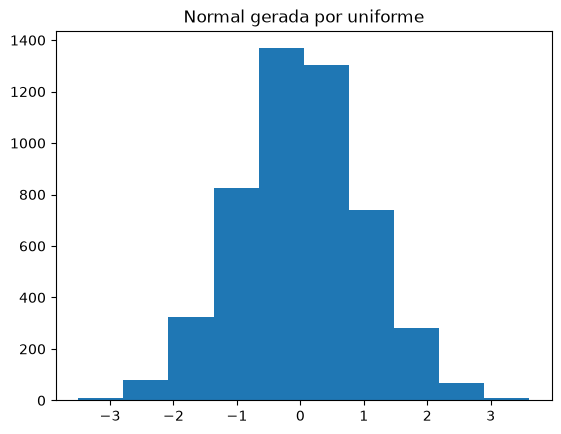

In [4]:
uniformes = np.random.uniform(size = (M, n))
normal_uni = normalizar(uniformes, n, 0.5, 1/12)
plt.hist(normal_uni)
plt.title('Normal gerada por uniforme')
plt.show()

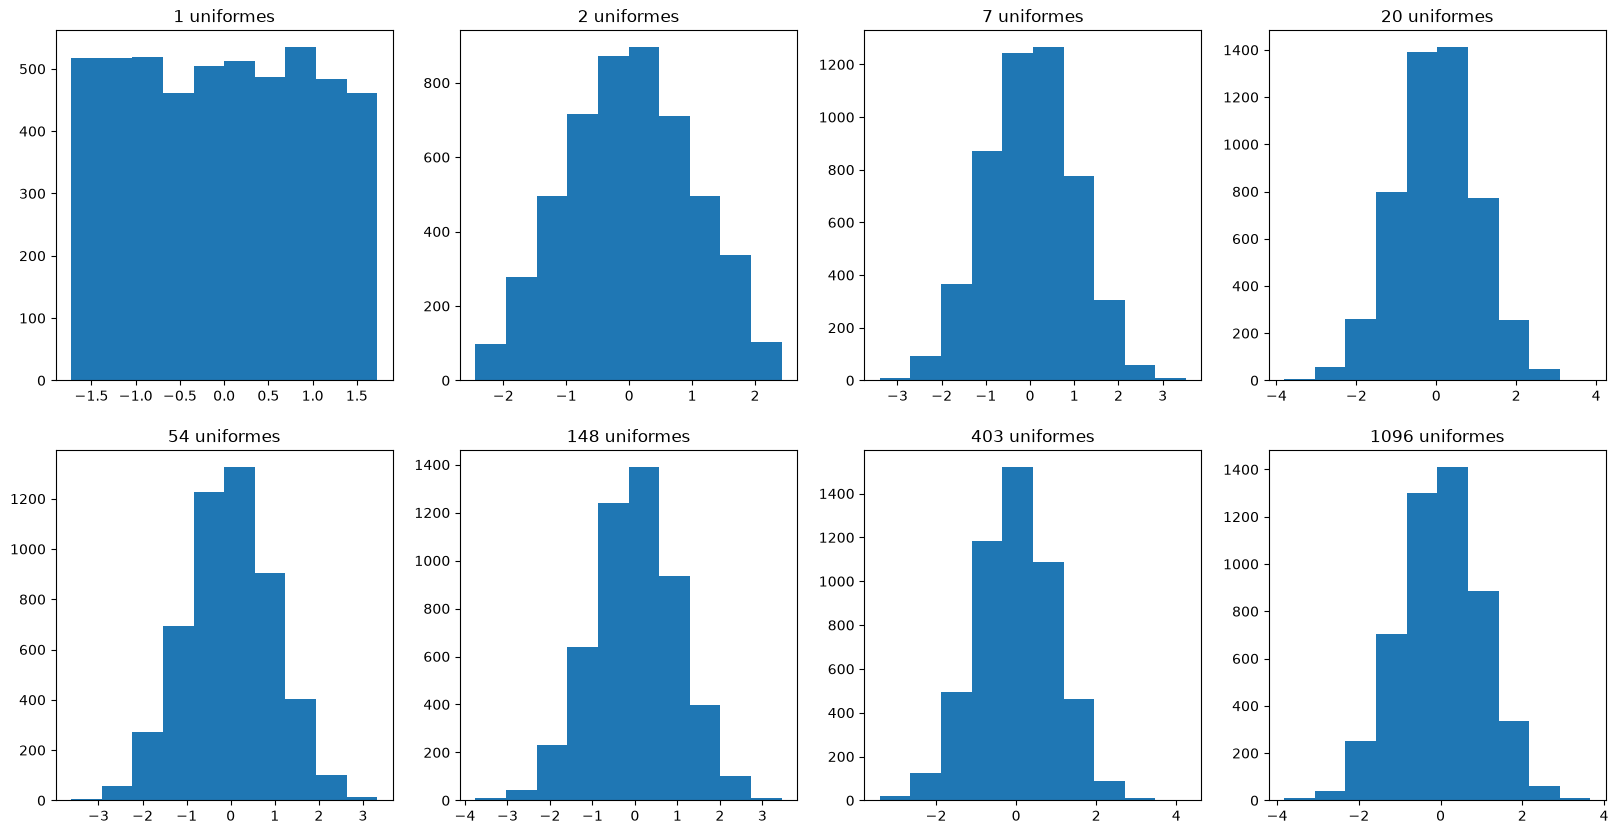

In [5]:
fig, ax = plt.subplots(2,4,figsize=(20,10))
ax = ax.flatten()
for i in range(8):
    n = int(np.exp(i))
    uniformes = np.random.uniform(size = (M, n))
    normal_uni = normalizar(uniformes, n, 0.5, 1/12)
    ax[i].hist(normal_uni)
    ax[i].set_title(f'{n} uniformes')
plt.show()

## Bernoulli

In [6]:
p = 0.3
bernoullis = uniformes < p
normal_bern = normalizar(bernoullis, n, p, p*(1-p))

Text(0.5, 1.0, 'Normal gerada por bernoullis')

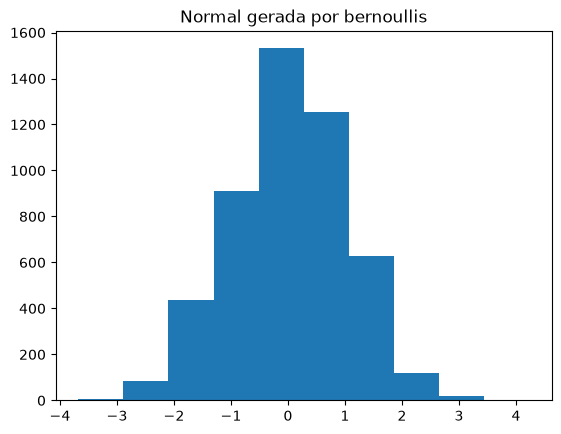

In [7]:
plt.hist(normal_bern)
plt.title('Normal gerada por bernoullis')

## Geométrica

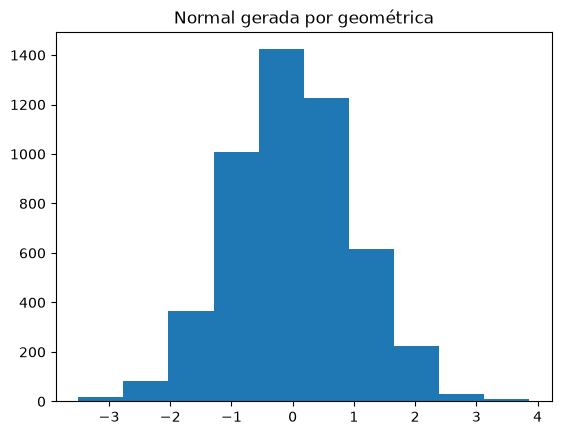

In [8]:
geo = np.ceil(np.log(uniformes)/np.log(1-p))
normal_geo = normalizar(geo, n, 1/p, (1-p)/p**2)
plt.hist(normal_geo)
plt.title('Normal gerada por geométrica')
plt.show()

# Exercício 2: Aproximação de Poisson

Como vimos em sala, se$X_n \sim \operatorname{Binomial}(n,p_n),$ com $p_n = \frac{\lambda}{n},$ então, para $\lambda > 0$ fixo,

$$
X_n \xrightarrow{d} \operatorname{Poisson}(\lambda)
$$

quando $n \to \infty$.

Em outras palavras, quando $n$ aumenta e $p_n$ diminui de forma que $np_n = \lambda,$ a distribuição $\operatorname{Binomial}(n,p_n)$ se aproxima de uma distribuição $\operatorname{Poisson}(\lambda)$.

1. Fixe um valor de $\lambda$ e um tamanho de amostra $M$. Para diferentes valores de $n$:

   * defina $p_n = \lambda/n$;
   * gere uma amostra de tamanho $M$ de variáveis

   $$
   X_n \sim \operatorname{Binomial}\left(n,\frac{\lambda}{n}\right);
   $$

   * compare as distribuições obtidas para diferentes valores de $n$ e analise o efeito do aumento de $n$ na aproximação pela distribuição de Poisson.

2. Para verificar a qualidade da aproximação, compare as amostras obtidas pelo método binomial com:

   * uma amostra de tamanho $M$ gerada diretamente por `numpy.random.poisson`;
   * uma amostra de tamanho $M$ de variáveis $\operatorname{Poisson}(\lambda)$ geradas utilizando o **método recursivo**.

3. Para cada método, construa histogramas ou gráficos de frequências e compare as distribuições empíricas obtidas.

4. Compare também o **tempo de execução** dos dois métodos:

   * aproximação por $\operatorname{Binomial}(n,\lambda/n)$;
   * geração de Poisson pelo método da inversão.


In [50]:
def poisson_recursiva(lamb,  M, n):
    p = lamb/n
    poisson = []
    for _ in range(M):
        U = np.random.uniform()
        i = 0
        pi = (1-p)**n
        F = pi
        while U > F:
            pi = (n-i) * p * pi/((i+1) * (1-p))
            i += 1
            F += pi
        poisson.append(i)
    return poisson

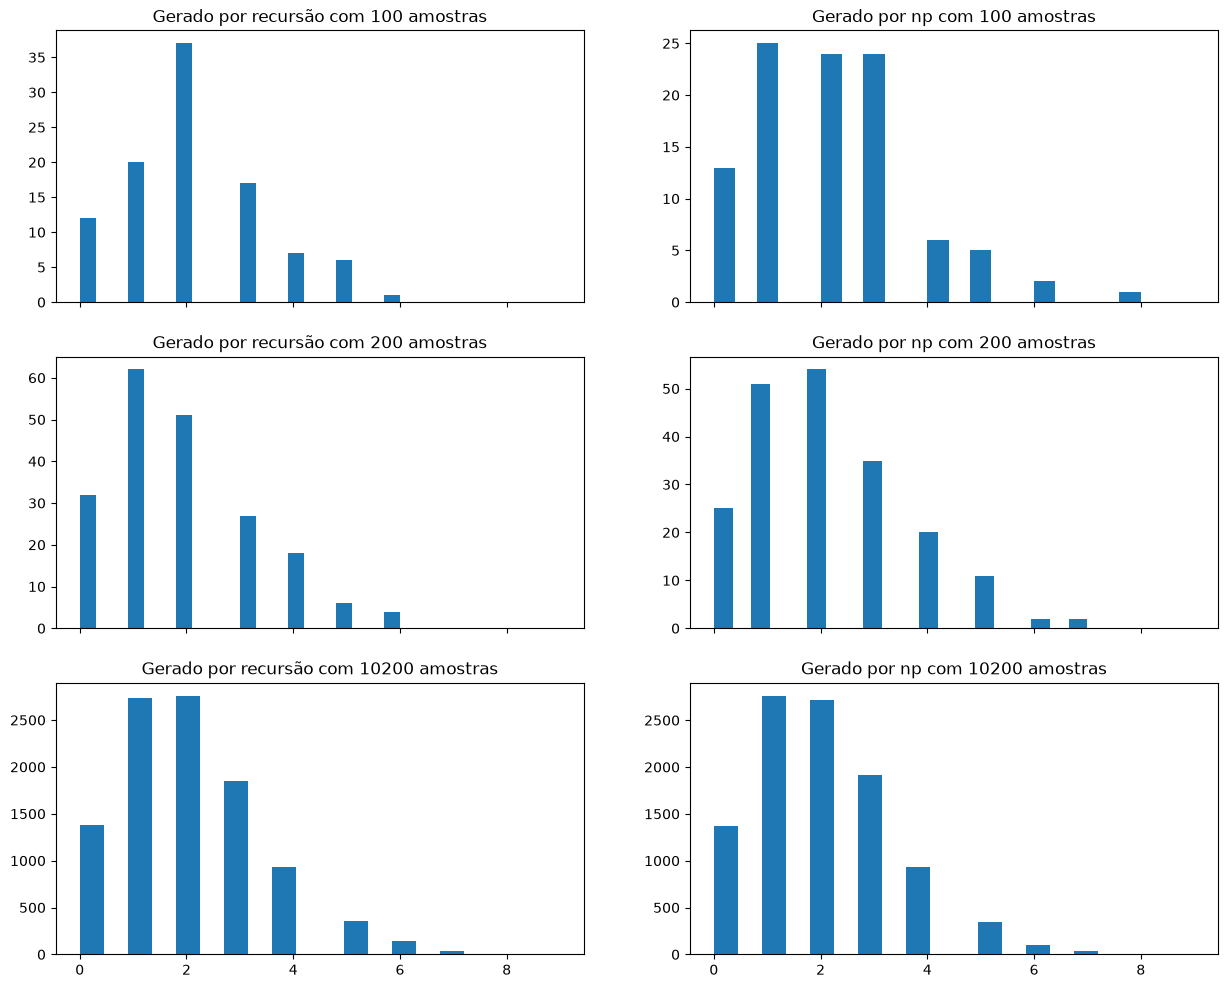

In [51]:
fig, ax = plt.subplots(3,2, figsize=(15,12), sharex= True)
M = 100
for i in range(3):
    poisson = poisson_recursiva(2, M, n)
    ax[i][0].hist(poisson, bins = 20)
    ax[i][1].hist(np.random.poisson(lamb, size = M), bins = 20)
    ax[i][0].set_title(f'Gerado por recursão com {M} amostras')
    ax[i][1].set_title(f'Gerado por np com {M} amostras')
    M += 100 ** (i + 1)
plt.show()

Podemos analisar que as amostras se assemelham cada vez mais com $M$ crescendo

In [66]:
M = 10_0000
n = 10_000
inicio = time.time()
poisson_recursiva(lamb, M, n)
print(f'Tempo para Poisson por recursao de binomial: {time.time() - inicio:.2f} segundos')

Tempo para Poisson por recursao de binomial: 0.63 segundos


In [67]:
inicio = time.time()
amostras_poisson = []
for _ in range(M):
    u = np.random.uniform()
    i = 0
    p = np.exp(-lamb) 
    cdf = p
    
    while u > cdf:
        i += 1
        p = p * lamb / i
        cdf += p
    amostras_poisson.append(i)
print(f'Tempo para Poisson por inversa: {time.time() - inicio:.2f} segundos')

Tempo para Poisson por inversa: 0.87 segundos


5. Discuta os resultados obtidos, considerando:

   * como o valor de $n$ influencia a qualidade da aproximação binomial-Poisson;
   * se as distribuições empíricas produzidas pelos três métodos são semelhantes;
   * as diferenças de tempo de execução entre os métodos;
   * as vantagens e desvantagens de cada método de geração.

- A distribuição se assemelha muito mais da poisson com n grande
- A por binomial foi a mais rápida, sem considerar a $np$
- O problema de ambos os métodos é o loop que acaba pesando muito a execução